<a href="https://colab.research.google.com/github/mvignesh0113-cloud/p/blob/main/projectmovie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline
sns.set_theme(style="whitegrid")


print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Dataset downloaded to:", path)
csv_filename = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_filename)

df = pd.read_csv(csv_path)


Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows


In [ ]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')


df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [ ]:
# 3. Handle date safely (errors='coerce' turns problematic dates to NaT instead of crashing)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Fill missing dates with the mode (most common date)
if df['date_added'].isnull().any():
    common_date = df['date_added'].mode()[0]
    df['date_added'] = df['date_added'].fillna(common_date)

# Extract year safely as integer
df['year_added'] = df['date_added'].dt.year.astype(int)

# Extract numeric duration values safely using raw string expression
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_num'] = df['duration_num'].fillna(df['duration_num'].median())

In [ ]:
("Null values after comprehensive cleaning:")
(df.isnull().sum())

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


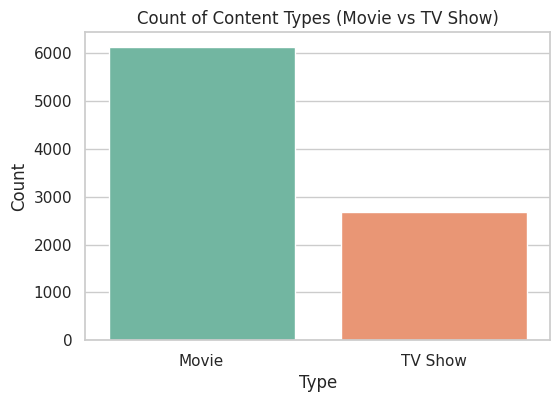

In [ ]:
# COUNTPLOT
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Count of Content Types (Movie vs TV Show)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

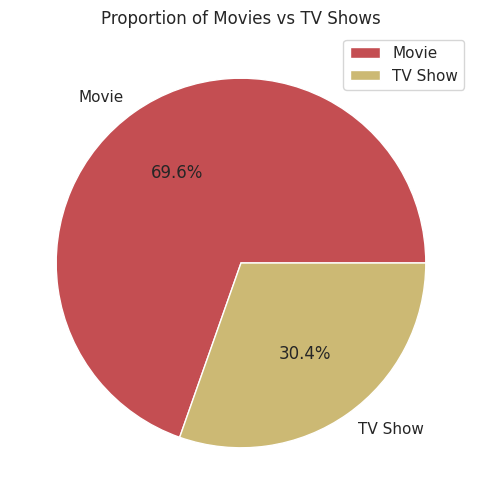

In [ ]:
#PIE CHART
plt.figure(figsize=(6, 6))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['r','y'])
plt.title('Proportion of Movies vs TV Shows')
plt.legend()
plt.show()

/tmp/ipykernel_6653/3709931559.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


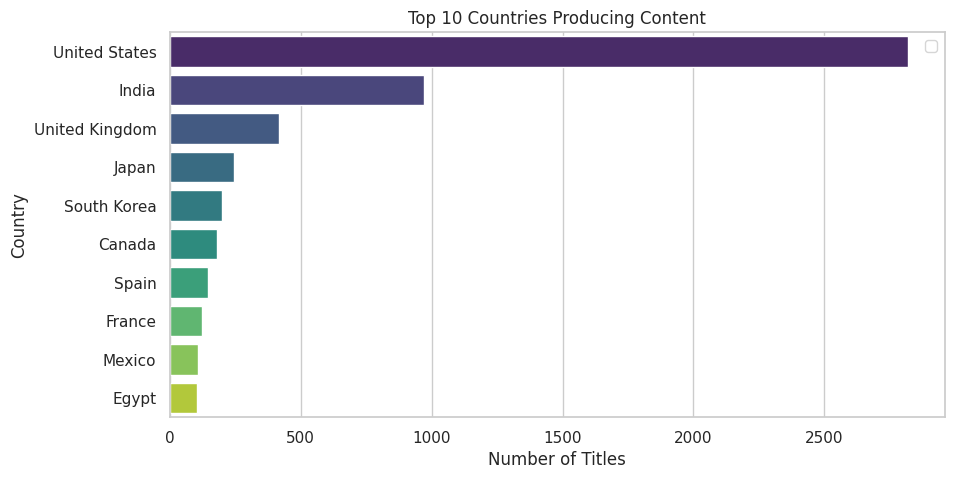

In [ ]:
#BAR CHART
plt.figure(figsize=(10, 5))
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis')
plt.title('Top 10 Countries Producing Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.legend()
plt.show()

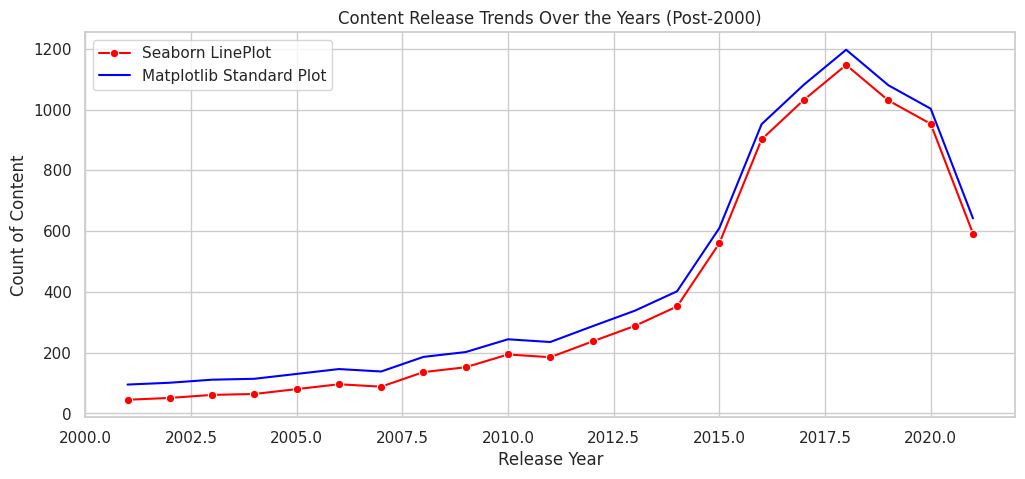

In [ ]:
#LINEPLOT & PLOT
release_by_year = df[df['release_year'] > 2000]['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=release_by_year.index, y=release_by_year.values, marker='o', color='red', label='Seaborn LinePlot')
plt.plot(release_by_year.index, release_by_year.values + 50,color='blue', label='Matplotlib Standard Plot')
plt.title('Content Release Trends Over the Years (Post-2000)')
plt.xlabel('Release Year')
plt.ylabel('Count of Content')
plt.legend()
plt.show()

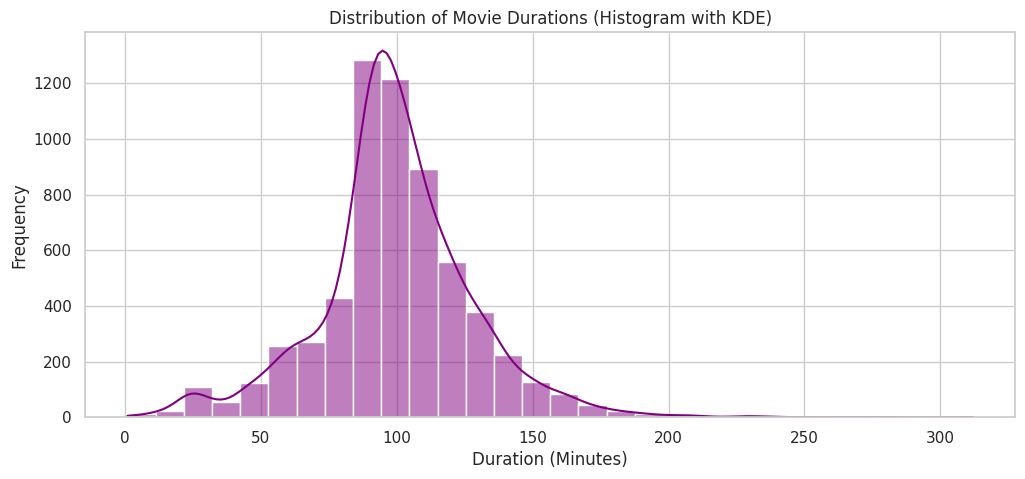

In [ ]:
#HISTPLOT & KDEPLOT
plt.figure(figsize=(12, 5))
movie_durations = df[(df['type'] == 'Movie') & (df['duration_num'].notnull())]
sns.histplot(data=movie_durations, x='duration_num', bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Durations (Histogram with KDE)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Frequency')
plt.show()

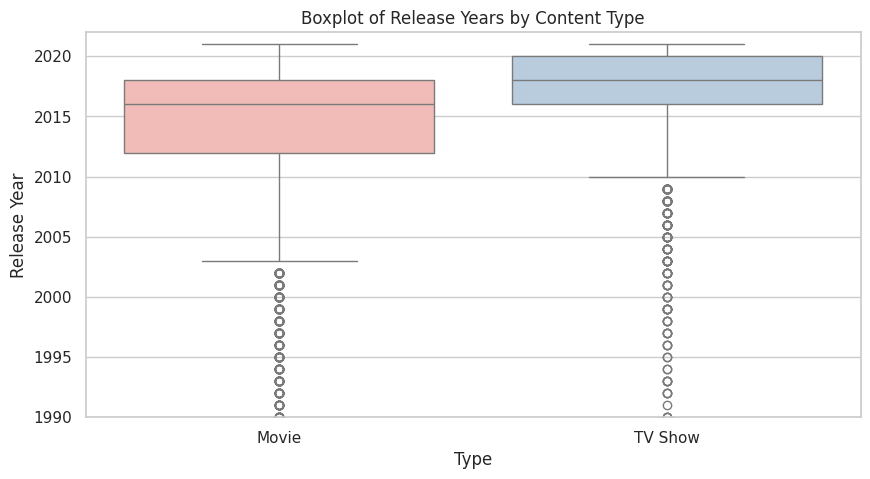

In [ ]:
#BOXPLOT
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='type', y='release_year', hue='type', palette='Pastel1', legend=False)
plt.title('Boxplot of Release Years by Content Type')
plt.xlabel('Type')
plt.ylabel('Release Year')
plt.ylim(1990, 2022)
plt.show()

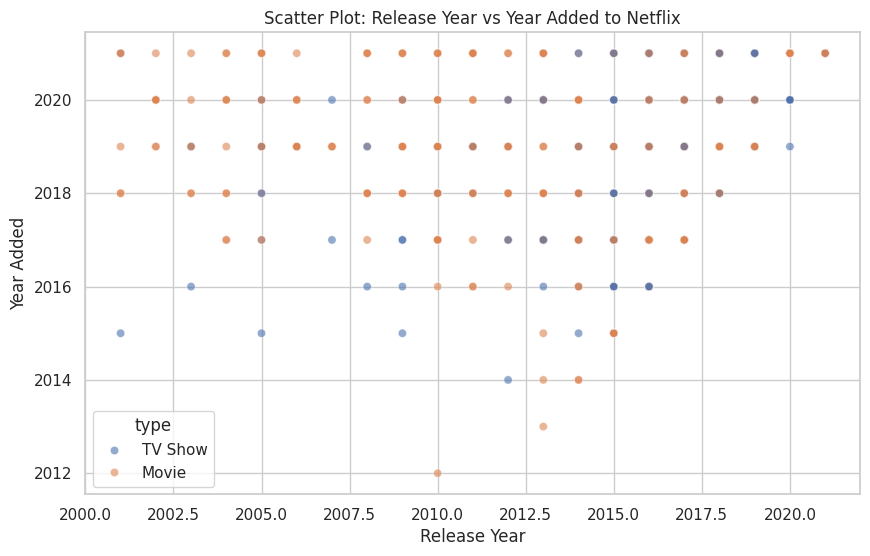

In [ ]:
#SCATTER PLOT
plt.figure(figsize=(10, 6))
sample_df = df[df['release_year'] > 2000].sample(min(1000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x='release_year', y='year_added', hue='type', alpha=0.6)
plt.title('Scatter Plot: Release Year vs Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added')
plt.show()

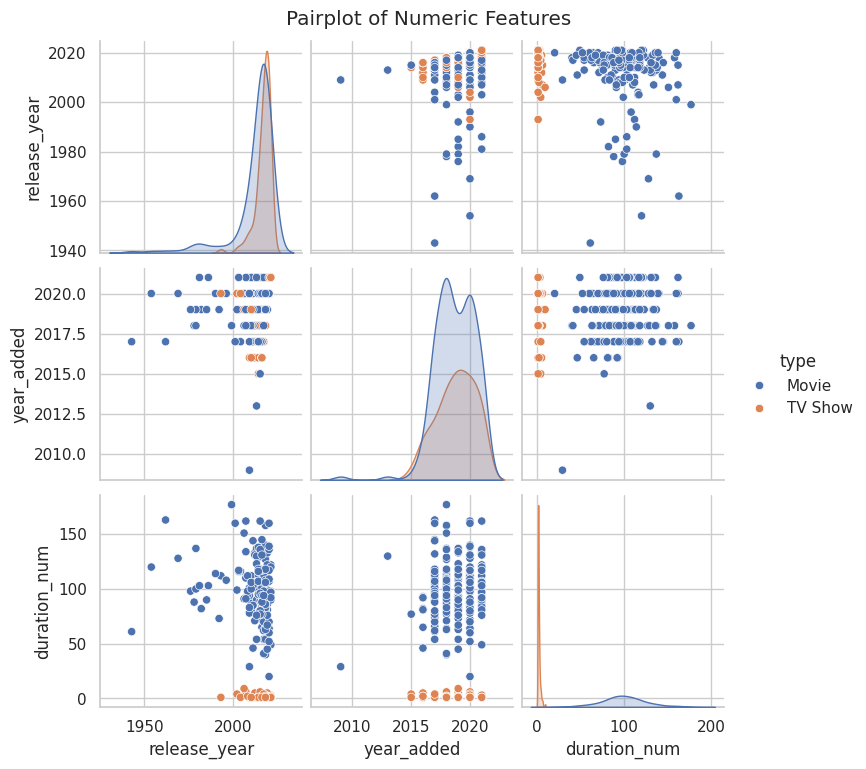

In [ ]:
#PAIRPLOT
numeric_cols = df[['release_year', 'year_added', 'duration_num', 'type']].dropna()
sns.pairplot(numeric_cols.sample(min(300, len(numeric_cols)), random_state=42), hue='type')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

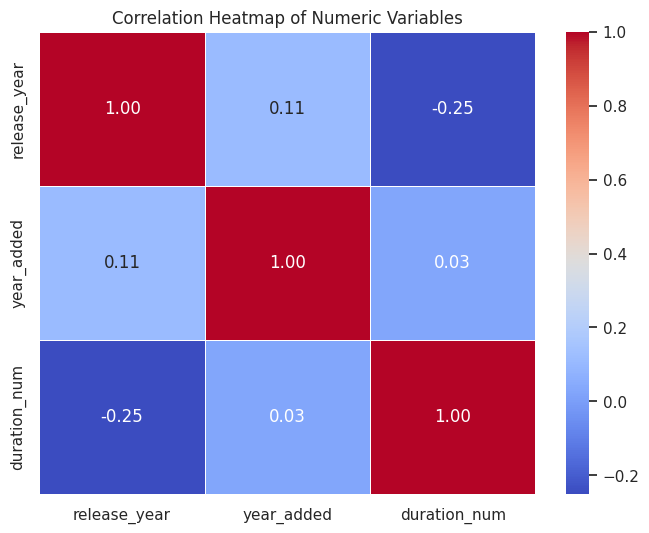

In [ ]:
#HEATMAP
plt.figure(figsize=(8, 6))
corr_matrix = df[['release_year', 'year_added', 'duration_num']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()